In [43]:
import scipy
import numpy as np

In [44]:
def boiler_heat_output(qin_boiler):
    qout_nom_boiler = 530.0
    eta_nom_boiler = 0.8
    lambda_in_min_boiler = 0.173
    lambda_out_min_boiler = 0.2
    beta_boiler = (1.0 - lambda_in_min_boiler) / (1.0 - lambda_out_min_boiler)
    qin_min_boiler = lambda_in_min_boiler * qout_nom_boiler / eta_nom_boiler
    qin_max_boiler = qout_nom_boiler / eta_nom_boiler

    if qin_boiler <= 0.0:
        return 0.0
    if qin_boiler < qin_min_boiler:
        return 0.0
    if qin_boiler > qin_max_boiler:
        qin_boiler = qin_max_boiler

    return qout_nom_boiler * (
        lambda_out_min_boiler
        + (1.0 / beta_boiler) * (qin_boiler * eta_nom_boiler / qout_nom_boiler - lambda_in_min_boiler)
    )


def chp_heat_output(qin_chp):
    qout_nom_chp = 470.0
    eta_nom_chp_th = 0.481
    lambda_in_min_chp = 0.582
    lambda_out_min_chp_th = 0.622
    beta_chp_th = (1.0 - lambda_in_min_chp) / (1.0 - lambda_out_min_chp_th)
    qin_min_chp = lambda_in_min_chp * qout_nom_chp / eta_nom_chp_th
    qin_max_chp = qout_nom_chp / eta_nom_chp_th

    if qin_chp <= 0.0:
        return 0.0
    if qin_chp < qin_min_chp:
        return 0.0
    if qin_chp > qin_max_chp:
        qin_chp = qin_max_chp

    return qout_nom_chp * (
        lambda_out_min_chp_th
        + (1.0 / beta_chp_th) * (qin_chp * eta_nom_chp_th / qout_nom_chp - lambda_in_min_chp)
    )


def chp_electricity_output(qin_chp):
    pout_nom_chp = 380.0
    eta_nom_chp_el = 0.389
    lambda_in_min_chp = 0.582
    lambda_out_min_chp_el = 0.5
    beta_chp_el = (1.0 - lambda_in_min_chp) / (1.0 - lambda_out_min_chp_el)
    qin_min_chp = lambda_in_min_chp * pout_nom_chp / eta_nom_chp_el
    qin_max_chp = 470.0 / 0.481

    if qin_chp <= 0.0:
        return 0.0
    if qin_chp < qin_min_chp:
        return 0.0
    if qin_chp > qin_max_chp:
        qin_chp = qin_max_chp

    return pout_nom_chp * (
        lambda_out_min_chp_el
        + (1.0 / beta_chp_el) * (qin_chp * eta_nom_chp_el / pout_nom_chp - lambda_in_min_chp)
    )


Maximum inputs: 
Boiler: 662.50
CHP: 977.13
Boiler heat linearization:        OUT = 0.8078 * IN   (MSE=540.8437)
CHP heat linearization:           OUT = 0.3948 * IN   (MSE=12215.2754)
CHP electricity linearization:    OUT = 0.2980 * IN   (MSE=7000.6649)


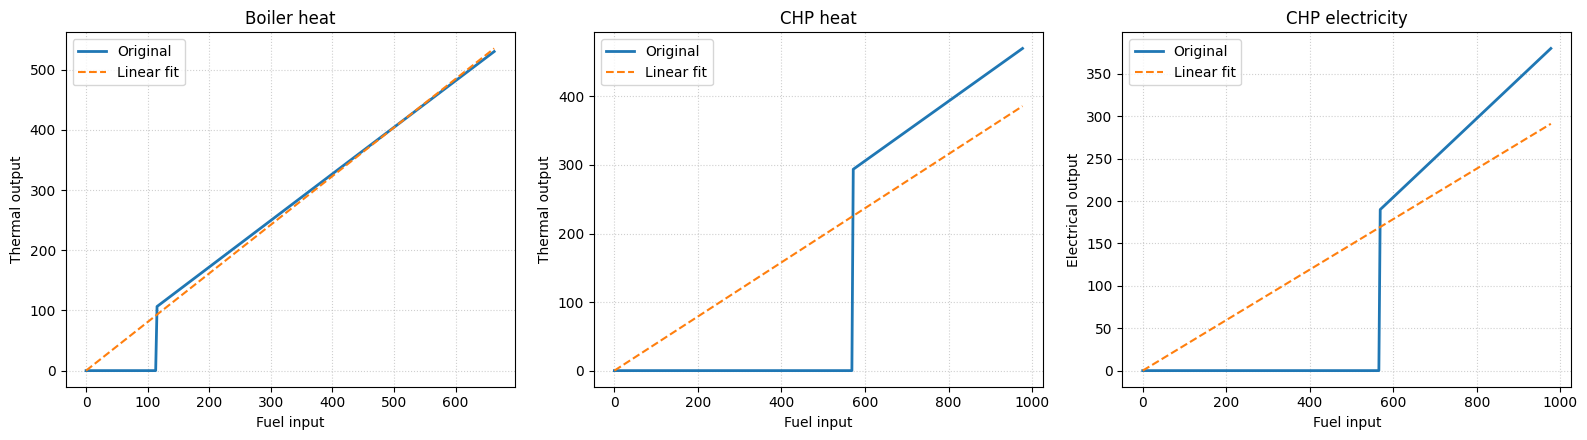

In [45]:
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt


def fit_linear_slope_through_origin(nonlinear_func, x_max, num_samples=400):
    x_values = np.linspace(0.0, x_max, num_samples)
    y_values = np.array([nonlinear_func(x) for x in x_values], dtype=float)

    def objective(m):
        y_linear = m * x_values
        return np.mean((y_linear - y_values) ** 2)

    result = minimize_scalar(objective, bounds=(0.0, 10.0), method="bounded")
    return result.x, result.fun


boiler_x_max = 530.0 / 0.8
chp_x_max = 470.0 / 0.481

print("Maximum inputs: ")
print(f"Boiler: {boiler_x_max:.2f}")
print(f"CHP: {chp_x_max:.2f}")

m_boiler_heat, err_boiler_heat = fit_linear_slope_through_origin(boiler_heat_output, boiler_x_max)
m_chp_heat, err_chp_heat = fit_linear_slope_through_origin(chp_heat_output, chp_x_max)
m_chp_el, err_chp_el = fit_linear_slope_through_origin(chp_electricity_output, chp_x_max)

print(f"Boiler heat linearization:        OUT = {m_boiler_heat:.4f} * IN   (MSE={err_boiler_heat:.4f})")
print(f"CHP heat linearization:           OUT = {m_chp_heat:.4f} * IN   (MSE={err_chp_heat:.4f})")
print(f"CHP electricity linearization:    OUT = {m_chp_el:.4f} * IN   (MSE={err_chp_el:.4f})")

x_boiler = np.linspace(0.0, boiler_x_max, 300)
x_chp = np.linspace(0.0, chp_x_max, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=False)

axes[0].plot(x_boiler, [boiler_heat_output(x) for x in x_boiler], label="Original", linewidth=2)
axes[0].plot(x_boiler, m_boiler_heat * x_boiler, label="Linear fit", linestyle="--")
axes[0].set_title("Boiler heat")
axes[0].set_xlabel("Fuel input")
axes[0].set_ylabel("Thermal output")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend()

axes[1].plot(x_chp, [chp_heat_output(x) for x in x_chp], label="Original", linewidth=2)
axes[1].plot(x_chp, m_chp_heat * x_chp, label="Linear fit", linestyle="--")
axes[1].set_title("CHP heat")
axes[1].set_xlabel("Fuel input")
axes[1].set_ylabel("Thermal output")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend()

axes[2].plot(x_chp, [chp_electricity_output(x) for x in x_chp], label="Original", linewidth=2)
axes[2].plot(x_chp, m_chp_el * x_chp, label="Linear fit", linestyle="--")
axes[2].set_title("CHP electricity")
axes[2].set_xlabel("Fuel input")
axes[2].set_ylabel("Electrical output")
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend()

fig.tight_layout()
plt.show()
fig.savefig("linearization_plots.png", dpi=300)

In [46]:
import sys
from pathlib import Path

# Walk up from CWD until we find the repo root (contains Erdem/ and Marius/)
_root = Path().resolve()
while _root != _root.parent:
    if (_root / "Erdem").is_dir():
        break
    _root = _root.parent

sys.path.insert(0, str(_root / "Erdem"))
VIZ_DIR = _root / "Marius" / "visualization"

from src.optimization.core import (
    m_B_heat_fitted, m_CHP_heat_fitted, m_CHP_el_fitted,
    m_B_heat_mean, m_CHP_heat_mean, m_CHP_el_mean,
    Q_out_nom_B, eta_nom_B,
    Q_out_nom_CHP, eta_nom_CHP_th,
)

print(f"Boiler heat:      fitted={m_B_heat_fitted:.4f}  mean_eff={m_B_heat_mean:.4f}")
print(f"CHP heat:         fitted={m_CHP_heat_fitted:.4f}  mean_eff={m_CHP_heat_mean:.4f}")
print(f"CHP electricity:  fitted={m_CHP_el_fitted:.4f}  mean_eff={m_CHP_el_mean:.4f}")
print(f"Output dir: {VIZ_DIR}")

Boiler heat:      fitted=0.8078  mean_eff=0.8624
CHP heat:         fitted=0.3948  mean_eff=0.4976
CHP electricity:  fitted=0.2980  mean_eff=0.3616
Output dir: D:\CODE\RWTH\ModE\Marius\visualization


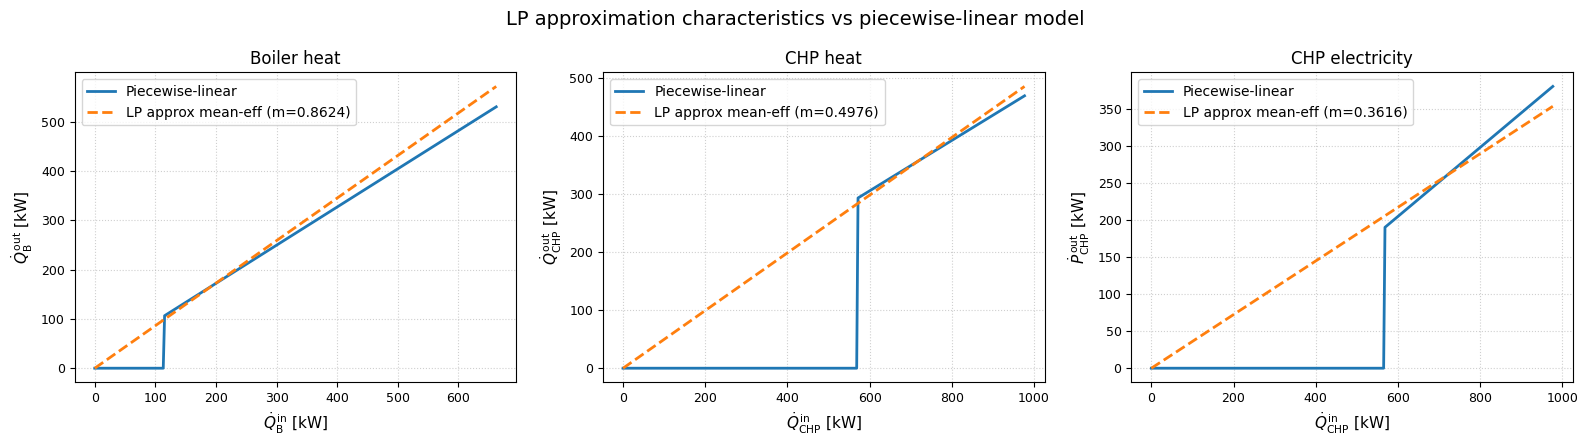

In [47]:
FS = 11  # base — change to rescale everything
FS_TICK    = FS - 2   # 9  tick labels
FS_LABEL   = FS       # 11 axis labels
FS_LEGEND  = FS - 1   # 10 legend
FS_TITLE   = FS + 1   # 12 subplot titles
FS_SUPTITLE = FS + 3  # 14 figure title

x_boiler = np.linspace(0.0, Q_out_nom_B / eta_nom_B, 300)
x_chp    = np.linspace(0.0, Q_out_nom_CHP / eta_nom_CHP_th, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=False)

axes[0].plot(x_boiler, [boiler_heat_output(x) for x in x_boiler],
             label="Piecewise-linear", linewidth=2, color="C0")
axes[0].plot(x_boiler, m_B_heat_mean * x_boiler,
             label=f"LP approx mean-eff (m={m_B_heat_mean:.4f})", linestyle="--", color="C1", linewidth=2)
axes[0].set_title("Boiler heat", fontsize=FS_TITLE)
axes[0].set_xlabel(r"$\dot{Q}^{\,\mathrm{in}}_{\mathrm{B}}$ [kW]", fontsize=FS_LABEL)
axes[0].set_ylabel(r"$\dot{Q}^{\,\mathrm{out}}_{\mathrm{B}}$ [kW]", fontsize=FS_LABEL)
axes[0].tick_params(labelsize=FS_TICK)
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(fontsize=FS_LEGEND)

axes[1].plot(x_chp, [chp_heat_output(x) for x in x_chp],
             label="Piecewise-linear", linewidth=2, color="C0")
axes[1].plot(x_chp, m_CHP_heat_mean * x_chp,
             label=f"LP approx mean-eff (m={m_CHP_heat_mean:.4f})", linestyle="--", color="C1", linewidth=2)
axes[1].set_title("CHP heat", fontsize=FS_TITLE)
axes[1].set_xlabel(r"$\dot{Q}^{\,\mathrm{in}}_{\mathrm{CHP}}$ [kW]", fontsize=FS_LABEL)
axes[1].set_ylabel(r"$\dot{Q}^{\,\mathrm{out}}_{\mathrm{CHP}}$ [kW]", fontsize=FS_LABEL)
axes[1].tick_params(labelsize=FS_TICK)
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(fontsize=FS_LEGEND)

axes[2].plot(x_chp, [chp_electricity_output(x) for x in x_chp],
             label="Piecewise-linear", linewidth=2, color="C0")
axes[2].plot(x_chp, m_CHP_el_mean * x_chp,
             label=f"LP approx mean-eff (m={m_CHP_el_mean:.4f})", linestyle="--", color="C1", linewidth=2)
axes[2].set_title("CHP electricity", fontsize=FS_TITLE)
axes[2].set_xlabel(r"$\dot{Q}^{\,\mathrm{in}}_{\mathrm{CHP}}$ [kW]", fontsize=FS_LABEL)
axes[2].set_ylabel(r"$\dot{P}^{\,\mathrm{out}}_{\mathrm{CHP}}$ [kW]", fontsize=FS_LABEL)
axes[2].tick_params(labelsize=FS_TICK)
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend(fontsize=FS_LEGEND)

fig.suptitle("LP approximation characteristics vs piecewise-linear model", fontsize=FS_SUPTITLE)
fig.tight_layout()
plt.show()
fig.savefig(VIZ_DIR / "lp_approx_characteristics.pdf", format="pdf", bbox_inches="tight")

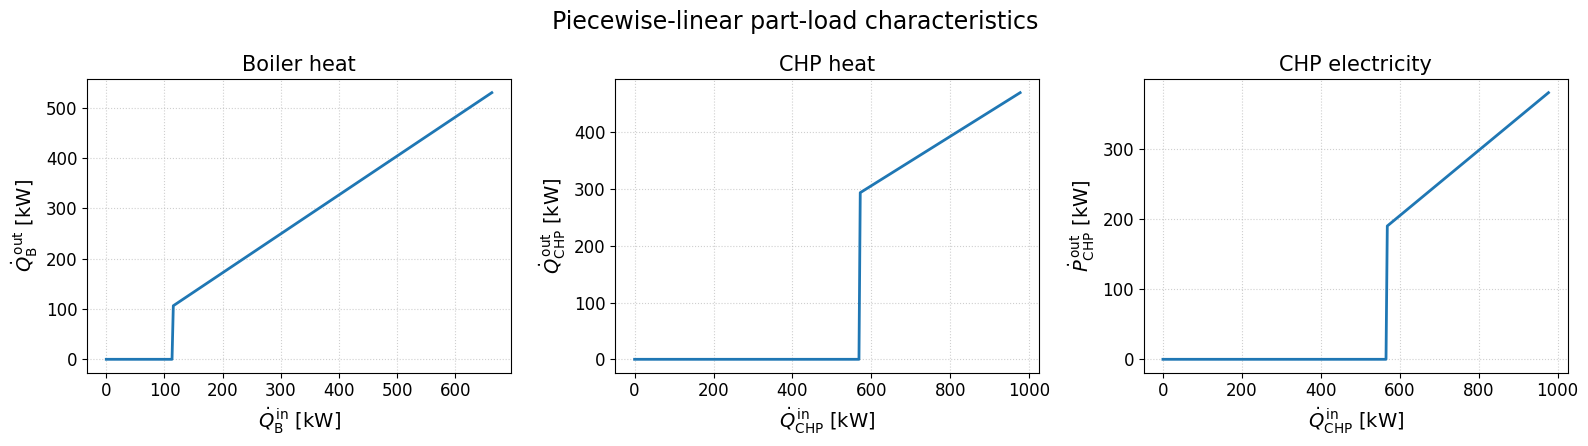

In [49]:
FS = 14  # base — change to rescale everything
FS_TICK     = FS - 2   # 9  tick labels
FS_LABEL    = FS       # 11 axis labels
FS_TITLE    = FS + 1   # 12 subplot titles
FS_SUPTITLE = FS + 3   # 14 figure title

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=False)

axes[0].plot(x_boiler, [boiler_heat_output(x) for x in x_boiler], linewidth=2, color="C0")
axes[0].set_title("Boiler heat", fontsize=FS_TITLE)
axes[0].set_xlabel(r"$\dot{Q}^{\,\mathrm{in}}_{\mathrm{B}}$ [kW]", fontsize=FS_LABEL)
axes[0].set_ylabel(r"$\dot{Q}^{\,\mathrm{out}}_{\mathrm{B}}$ [kW]", fontsize=FS_LABEL)
axes[0].tick_params(labelsize=FS_TICK)
axes[0].grid(True, linestyle=":", alpha=0.6)

axes[1].plot(x_chp, [chp_heat_output(x) for x in x_chp], linewidth=2, color="C0")
axes[1].set_title("CHP heat", fontsize=FS_TITLE)
axes[1].set_xlabel(r"$\dot{Q}^{\,\mathrm{in}}_{\mathrm{CHP}}$ [kW]", fontsize=FS_LABEL)
axes[1].set_ylabel(r"$\dot{Q}^{\,\mathrm{out}}_{\mathrm{CHP}}$ [kW]", fontsize=FS_LABEL)
axes[1].tick_params(labelsize=FS_TICK)
axes[1].grid(True, linestyle=":", alpha=0.6)

axes[2].plot(x_chp, [chp_electricity_output(x) for x in x_chp], linewidth=2, color="C0")
axes[2].set_title("CHP electricity", fontsize=FS_TITLE)
axes[2].set_xlabel(r"$\dot{Q}^{\,\mathrm{in}}_{\mathrm{CHP}}$ [kW]", fontsize=FS_LABEL)
axes[2].set_ylabel(r"$\dot{P}^{\,\mathrm{out}}_{\mathrm{CHP}}$ [kW]", fontsize=FS_LABEL)
axes[2].tick_params(labelsize=FS_TICK)
axes[2].grid(True, linestyle=":", alpha=0.6)

fig.suptitle("Piecewise-linear part-load characteristics", fontsize=FS_SUPTITLE)
fig.tight_layout()
plt.show()
fig.savefig(VIZ_DIR / "characteristics.pdf", format="pdf", bbox_inches="tight")